<a href="https://colab.research.google.com/github/hecfrantuis/Proyecto-IA-1/blob/main/Proyecto_AcneI_A1_Exploracion_Datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Drive - Librerias

In [3]:
#@title Montar el drive
import os
from google.colab import drive

Ubicacion = "Septimo/IA 1 2026-1/Proyecto/AcneDataset/train" #@param {type:"string"}
path = "/content/drive/My Drive/" + Ubicacion
drive.mount('/content/drive')
os.chdir(path)
print(os.getcwd())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/My Drive/Septimo/IA 1 2026-1/Proyecto/AcneDataset/train


In [4]:
# @title Librerias
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
from sklearn.preprocessing import LabelEncoder

# Exploracion de datos del dataset

In [5]:
# @title Configuracion de Matplotlib y Seaborn
sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.family'] = 'sans-serif'

In [6]:
# @title Listar las carpetas y contar imágenes por carpeta
categorias = [f for f in os.listdir('.') if os.path.isdir(f)]
conteo = {cat: len(os.listdir(cat)) for cat in categorias}

# Mostrar en una tabla simple
df_stats = pd.DataFrame(conteo.items(), columns=['Nivel de Acné', 'Cantidad de Imágenes'])
print(df_stats)

  Nivel de Acné  Cantidad de Imágenes
0    Blackheads                   735
1          Cyst                   645
2       Papules                   621
3      Pustules                   584
4    Whiteheads                   193


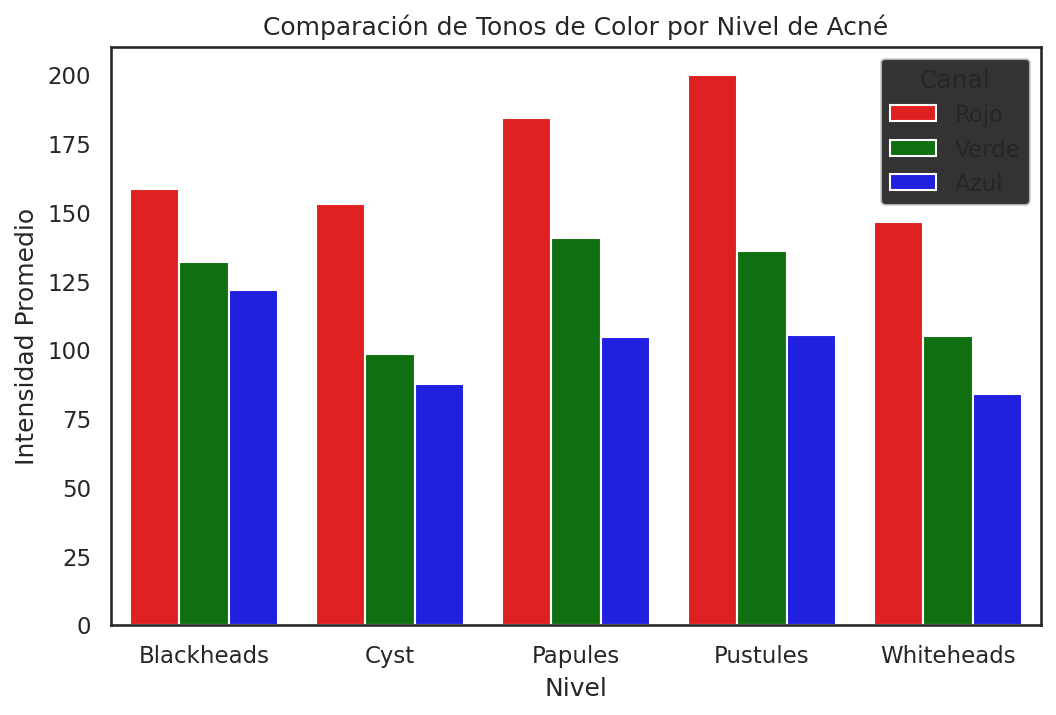

In [26]:
# @title Distribución de color por Patologia
def analizar_color(ruta_imagen):
    img = cv2.imread(ruta_imagen)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    # Calculamos el promedio de cada canal (R, G, B)
    promedios = np.mean(img, axis=(0, 1))
    return promedios

# Tomamos una muestra de cada categoría para comparar
resultados_color = []
for cat in categorias:
    carpeta_cat = os.path.join(path, cat)
    primera_img = os.path.join(carpeta_cat, os.listdir(carpeta_cat)[0])
    r, g, b = analizar_color(primera_img)
    resultados_color.append({'Nivel': cat, 'Rojo': r, 'Verde': g, 'Azul': b})

df_color = pd.DataFrame(resultados_color)

# Graficar para el avance del proyecto
plt.figure(figsize=(8, 5))
df_melt = df_color.melt(id_vars='Nivel', var_name='Canal', value_name='Intensidad Promedio')
sns.barplot(data=df_melt, x='Nivel', y='Intensidad Promedio', hue='Canal', palette=['red', 'green', 'blue'])
plt.title("Comparación de Tonos de Color por Nivel de Acné")
plt.show()

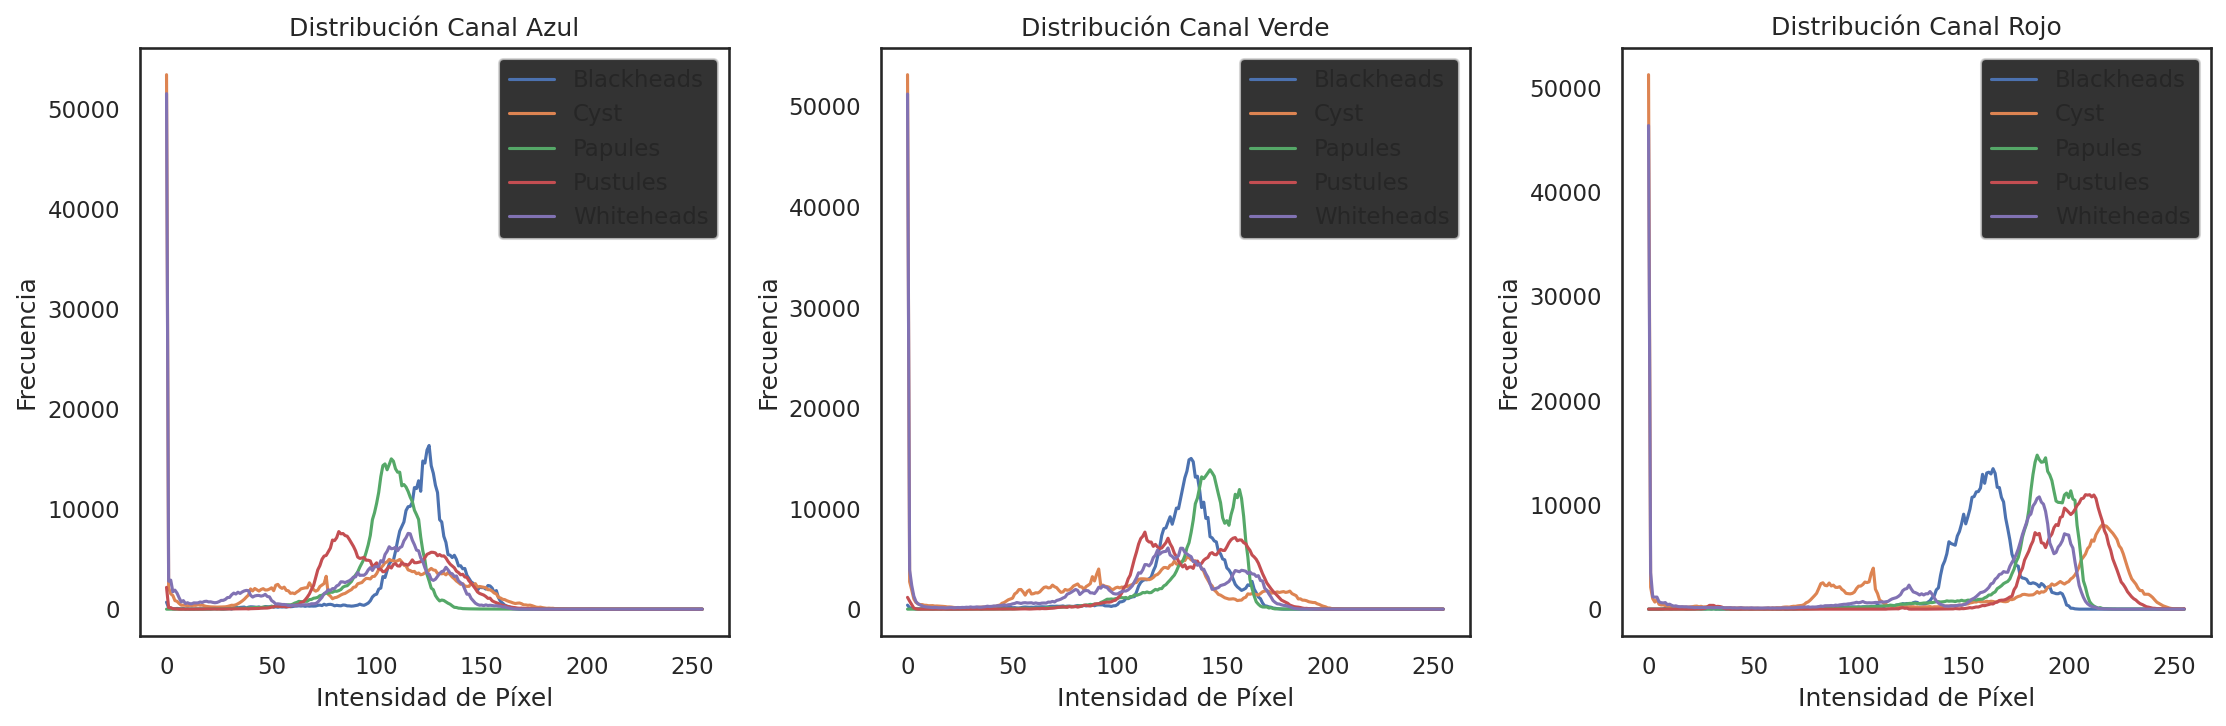

In [23]:
# @title Histogramas Comparativos de color
def graficar_comparativa_histogramas(ruta_base, categorias):
    plt.figure(figsize=(15, 5))
    colores = ('b', 'g', 'r')
    nombres_canales = ('Azul', 'Verde', 'Rojo')

    for i, col in enumerate(colores):
        plt.subplot(1, 3, i+1)
        for cat in categorias:
            # Tomamos una imagen representativa de cada carpeta
            folder = os.path.join(ruta_base, cat)
            img_name = os.listdir(folder)[0]
            img = cv2.imread(os.path.join(folder, img_name))

            # Calcular histograma para el canal actual
            hist = cv2.calcHist([img], [i], None, [256], [0, 256])
            plt.plot(hist, label=cat)

        plt.title(f'Distribución Canal {nombres_canales[i]}')
        plt.xlabel('Intensidad de Píxel')
        plt.ylabel('Frecuencia')
        plt.legend()

    plt.tight_layout()
    plt.show()

categorias = ['Blackheads', 'Cyst', 'Papules', 'Pustules', 'Whiteheads']
graficar_comparativa_histogramas(path, categorias)

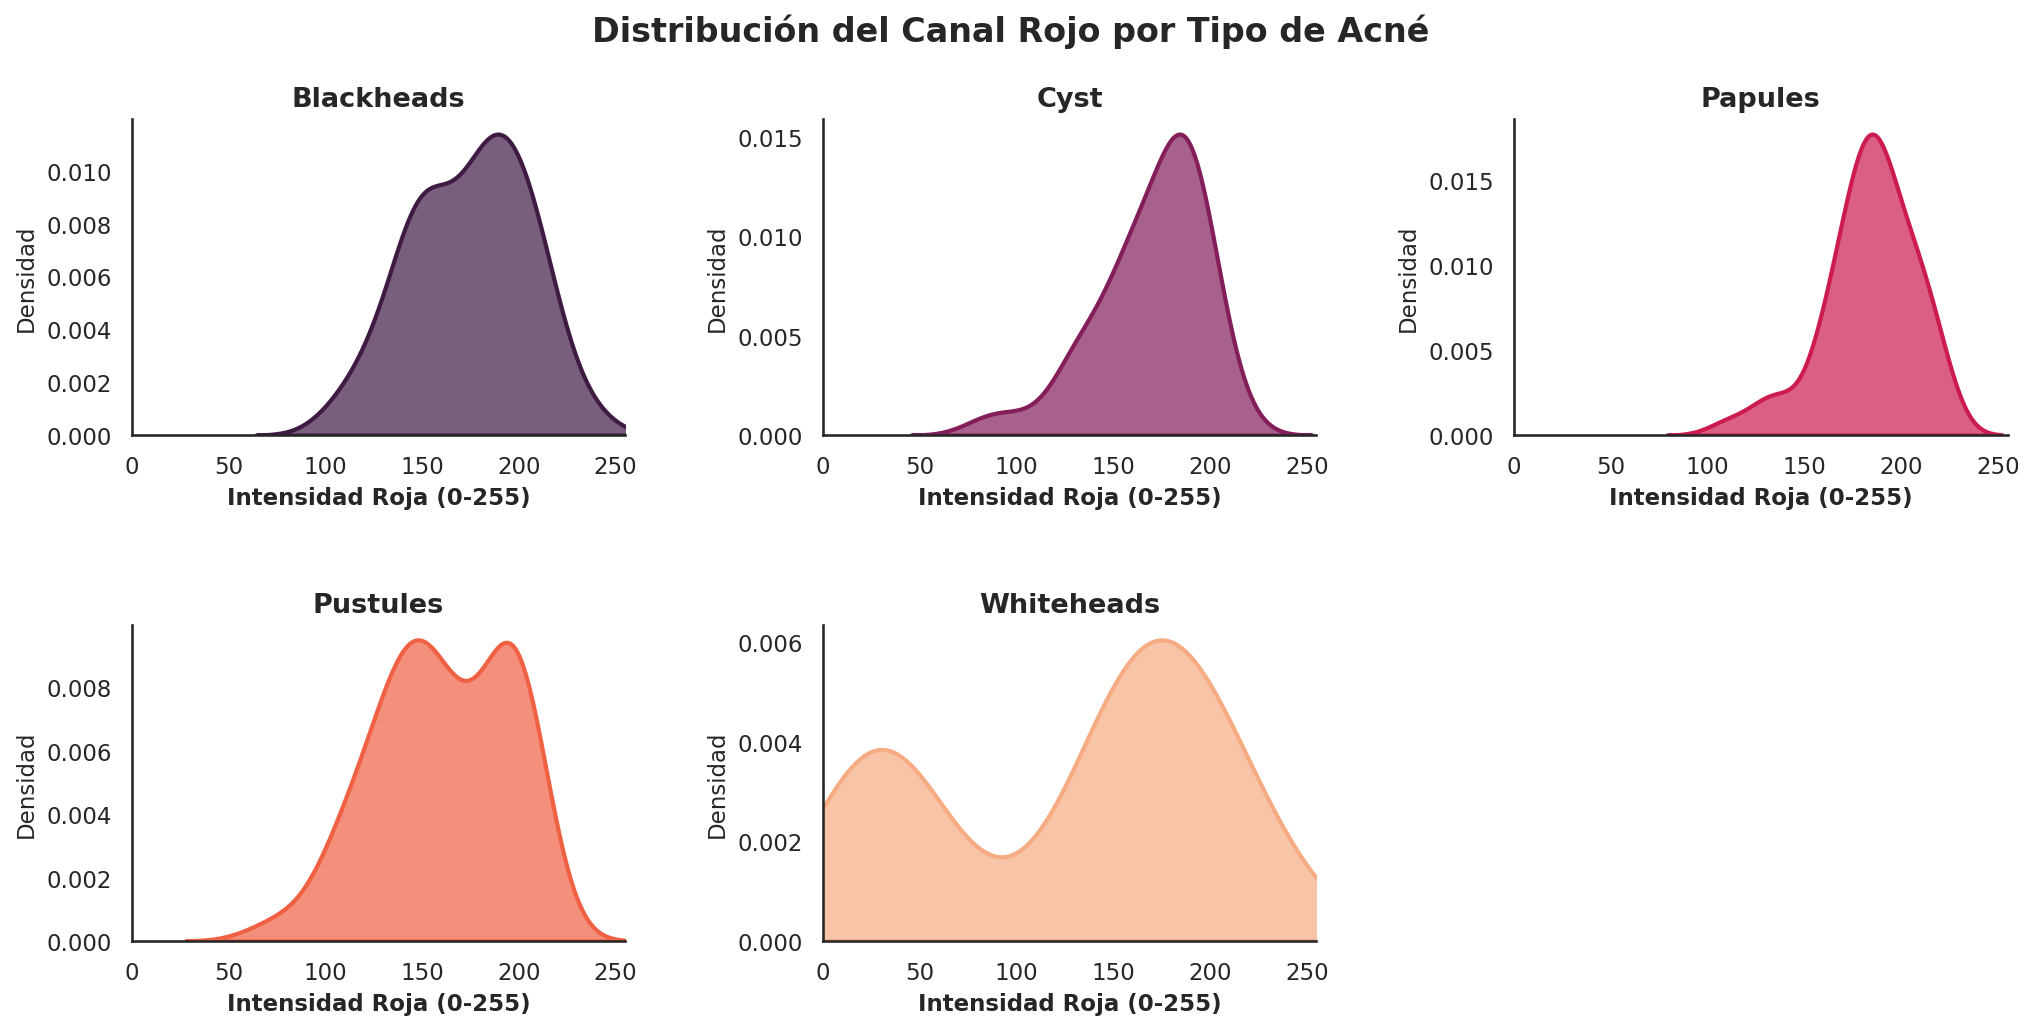

In [24]:
# @title Distribucion del color **rojo** por patologia

def extraer_datos_proyecto(ruta_base, categorias, n_muestras=50):
    recolector = []

    for cat in categorias:
        folder = os.path.join(ruta_base, cat)
        if not os.path.isdir(folder): continue

        # Tomamos una muestra para que el proceso sea rápido
        imagenes = [f for f in os.listdir(folder) if f.endswith(('.jpg', '.png', '.jpeg'))][:n_muestras]

        for img_name in imagenes:
            img_path = os.path.join(folder, img_name)
            img = cv2.imread(img_path)

            if img is not None:
                # 1. Color Promedio (RGB)
                avg_color = np.mean(img, axis=(0, 1))
                # 2. Contraste (Varianza en escala de grises)
                gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
                contraste = np.var(gris)

                recolector.append({
                    'Categoria': cat,
                    'Rojo': avg_color[2],
                    'Verde': avg_color[1],
                    'Azul': avg_color[0],
                    'Contraste': contraste
                })

    return pd.DataFrame(recolector)

def grafico_distribucion_clara(df):
    # Agregamos sharex=False y sharey=False para que Seaborn las trate como gráficas independientes
    g = sns.FacetGrid(df, col="Categoria", hue="Categoria", col_wrap=3,
                      palette="rocket", height=3.5, aspect=1.3, sharex=False, sharey=False)

    # Dibujamos la densidad
    g.map(sns.kdeplot, "Rojo", fill=True, alpha=0.7, linewidth=2)

    # Títulos individuales
    g.set_titles("{col_name}", fontweight='bold', size=13)

    # --- LA SOLUCIÓN DEFINITIVA ---
    for ax in g.axes.flatten():
        ax.set_xlim(0, 255) # Límite real del color
        # Forzamos los textos en CADA una de las gráficas
        ax.set_xlabel("Intensidad Roja (0-255)", fontsize=11, fontweight='bold')
        ax.set_ylabel("Densidad", fontsize=11)
    # ------------------------------

    # Aumentamos wspace (espacio horizontal) y hspace (vertical) para que los textos no choquen
    plt.subplots_adjust(top=0.88, hspace=0.6, wspace=0.4)

    g.fig.suptitle('Distribución del Canal Rojo por Tipo de Acné', fontsize=16, fontweight='bold')
    plt.show()

categorias_acne = [f for f in os.listdir(path) if os.path.isdir(os.path.join(path, f))]
df_proyecto = extraer_datos_proyecto(path, categorias_acne)
grafico_distribucion_clara(df_proyecto)

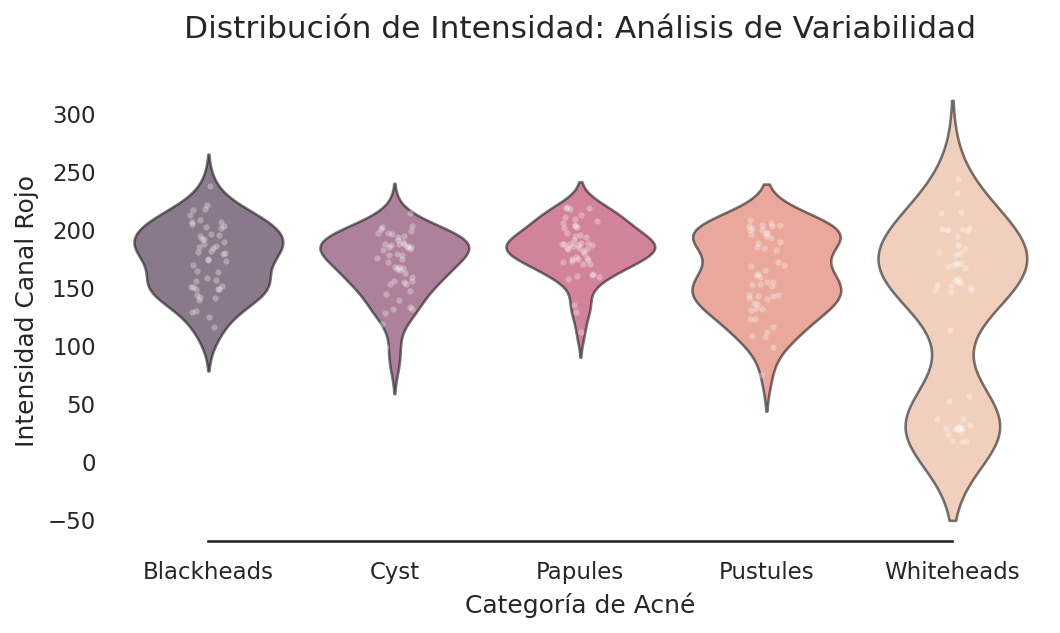

In [19]:
# @title Distribucion de la intensidad
def grafico_violin_impacto(df):
    plt.figure(figsize=(8, 4))

    # El violín muestra la densidad
    sns.violinplot(
        data=df,
        x='Categoria',
        y='Rojo',
        hue='Categoria',
        legend=False,
        inner=None,
        palette="rocket",
        alpha=0.6
    )

    # Superponemos los puntos reales (jitter) para ver la muestra completa
    sns.stripplot(data=df, x='Categoria', y='Rojo', color="white", edgecolor="black",
                  size=3, alpha=0.3, jitter=True)

    plt.title("Distribución de Intensidad: Análisis de Variabilidad", fontsize=15, pad=20)
    plt.xlabel("Categoría de Acné", fontsize=12)
    plt.ylabel("Intensidad Canal Rojo", fontsize=12)
    sns.despine(trim=True, left=True)
    plt.show()

grafico_violin_impacto(df_proyecto)

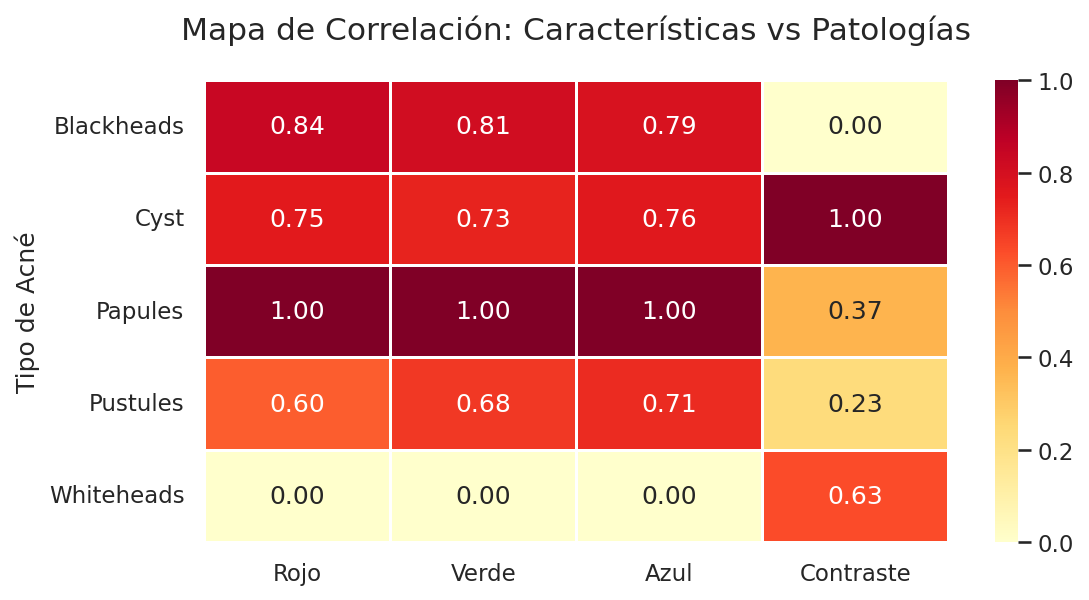

In [17]:
# @title Mapa de correlacion entre los colores-contraste vs la patologia
def grafico_heatmap_correlacion(df):
    # Agrupamos por categoría y sacamos el promedio
    df_resumen = df.groupby('Categoria').mean()

    # Normalizamos para que la comparación sea visualmente clara (0 a 1)
    df_norm = (df_resumen - df_resumen.min()) / (df_resumen.max() - df_resumen.min())

    plt.figure(figsize=(8, 4))
    sns.heatmap(df_norm, annot=True, cmap="YlOrRd", fmt=".2f", linewidths=.5)

    plt.title("Mapa de Correlación: Características vs Patologías", fontsize=15, pad=20)
    plt.ylabel("Tipo de Acné")
    plt.show()

grafico_heatmap_correlacion(df_proyecto)

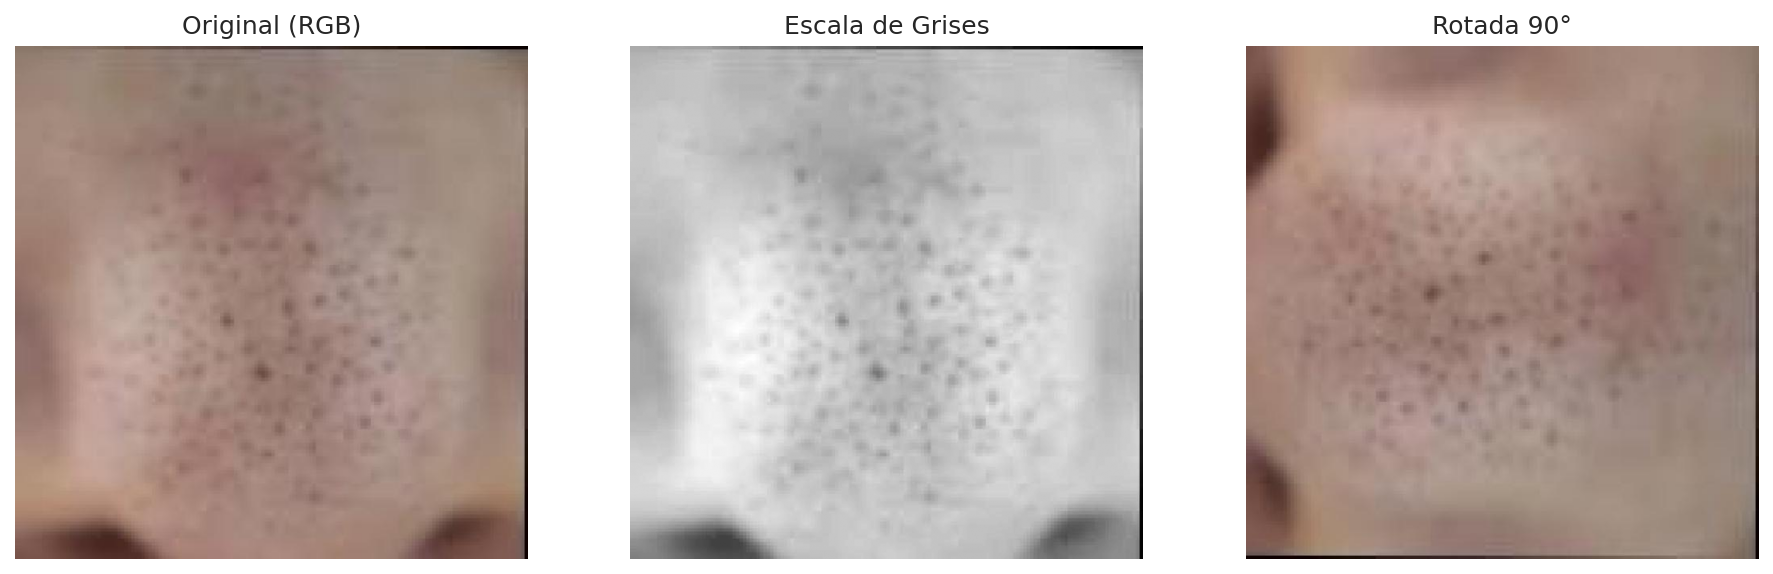

In [27]:
# @title Visualización de Procesamiento (Original vs. Transformada)
# Elegir una imagen de prueba
img_prueba_path = os.path.join(path, categorias[0], os.listdir(categorias[0])[0])
img_original = cv2.imread(img_prueba_path)
img_original = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB)

# Procesamiento
img_gris = cv2.cvtColor(img_original, cv2.COLOR_RGB2GRAY)
img_rotada = cv2.rotate(img_original, cv2.ROTATE_90_CLOCKWISE)

# Mostrar resultados en una sola fila
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(img_original)
ax[0].set_title("Original (RGB)")
ax[1].imshow(img_gris, cmap='gray')
ax[1].set_title("Escala de Grises")
ax[2].imshow(img_rotada)
ax[2].set_title("Rotada 90°")
for a in ax: a.axis('off')
plt.show()